In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
data1=np.linspace(0,1,10)
data2=[0.5+0.5*np.cos(np.pi*((i-0.5)/10)) for i in range(1,11)]
datas=[data1, data2]
data1=np.array(data1)
data2=np.array(data2)
datas=np.array(datas)
R_matrix=np.zeros([len(data2), len(data2)])
x=np.linspace(0,1,1000)

# IMSE Calculation

In [2]:
def R(x, theta=0.1):
    return np.exp(-((x**2)/(theta**2)))

def r(x, data):
    x_R=x-data
    return R(x_R)

def s(x, R_matrix,  data):
    return np.sqrt(1-r(x, data).T@np.linalg.inv(R_matrix)@r(x, data))

In [3]:
def IMSE(datas,x):
    if len(datas.shape)==1:
        datas=datas.reshape(1,-1)
    output=[]
    del_x=x[1]-x[0]
    for data in datas:
        areas=np.zeros([len(data), len(data)])
        ys=[]
        r_matrix=[]
        R_matrix=[]
        for i in x:
            r_x=r(np.array([i]), data)
            r_x=r_x.reshape(-1,1)
            ys.append(r_x@r_x.T)
        for j in data:
            R_matrix.append(r(np.array(j), data))
        R_matrix=np.array(R_matrix)
        inverse=np.linalg.inv(R_matrix)  
        ys=np.array(ys)
    
        for index in range(len(ys)-1):
            areas=areas+(1/2)*(ys[index]+ys[index+1])*del_x
        output.append(1-np.trace(inverse@areas))
    
    return np.array(output)
imse=IMSE(datas, x)       

# RMSE for equispaced and Chevyshevs points

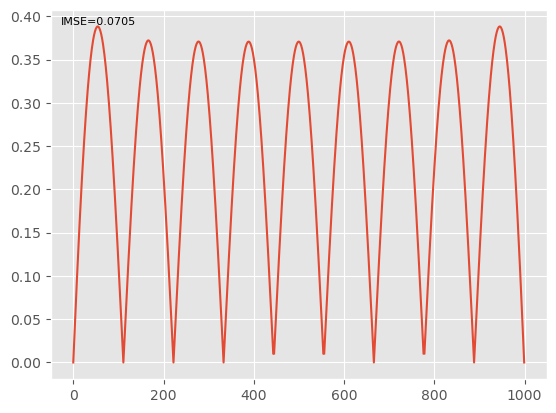

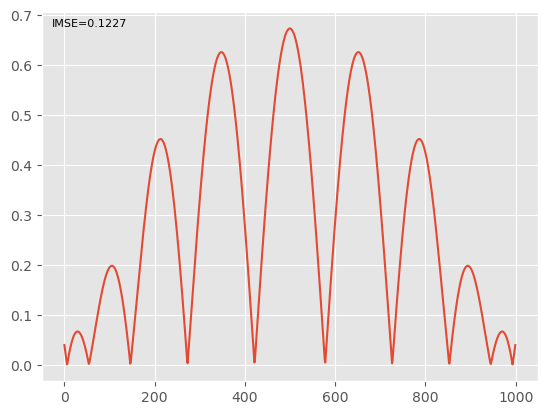

In [4]:

for index, data in enumerate(datas):
    for i in range(len(data)):
        for j in range(len(data)):
            R_matrix[i,j]=R(data[i]-data[j])

    s_=[]
    for i in x:
        s_.append(s(i, R_matrix, data))
    fig, ax = plt.subplots()
    
    ax.plot(s_)
    ax.text(
        0.02, 0.98,
        f"IMSE={imse[index]:.4f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8

    )

## Gradieant of IMSE

In [13]:
def Grad_IMSE(data, x, epsilon=0.01):
    output=[]
    IMSE_k=IMSE(data, x)
    for index, element in enumerate(data):
        edited_data_post=data.copy()
        edited_data_pre=data.copy()
        edited_data_post[index]=element+epsilon
        edited_data_pre[index]=element-epsilon
        IMSE_post=IMSE(edited_data_post, x)
        IMSE_pre=IMSE(edited_data_pre, x)
        output.append((IMSE_post-IMSE_pre)/(2*epsilon))
    #grad_post=(IMSE_post-IMSE_k)/epsilon
    #grad_pre=(IMSE_k-IMSE_pre)/epsilon
    return (np.array(output)).reshape(1, -1)

In [14]:
print(Grad_IMSE(data1, x))

[[-3.73098968e-01 -1.43716361e-02 -1.23732459e-04  1.12901396e-04
   1.78941561e-05 -1.78941562e-05 -1.12901396e-04  1.23732459e-04
   1.43716361e-02  3.73098968e-01]]


In [15]:
def H_k(rho_k, s_k, y_k, H):
    s_k=s_k.reshape(1, -1)
    y_k=y_k.reshape(1, -1)
    length=len(H)
    return (np.eye(length)-rho_k*s_k.T@y_k)@H@(np.eye(length)-rho_k*y_k.T@s_k)+rho_k*s_k.T@s_k

In [16]:
epsilon=0.01
learning_rate=0.01
H=np.eye(len(data1))
grad_initial=Grad_IMSE(data1, x, epsilon)
p_k=-H@grad_initial
D_new=data1+learning_rate*p_k
s_k=D_new-data1
y_k=Grad_IMSE(D_new, x, epsilon)-Grad_IMSE(data1, x, epsilon)
rho_k=1/(y_k@s_k)
H_new=H_k(rho_k, s_k, y_k, H)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 10)

In [8]:
test=np.array([1,2,3])

In [9]:
test=test.reshape(-1,1)

In [10]:
test.shape

(3, 1)